Case Study: Analisis Data FMCG

## 🎯 Objective
Kita akan menganalisis dataset penjualan FMCG nyata dari perusahaan yang menjual produk kebutuhan sehari-hari melalui berbagai channel (Offline, Online Toko Oren, Online Toko Hijau).

Dataset ini **messy**, mengandung berbagai masalah data yang harus dibersihkan sebelum dianalisis.

### Business Questions:
1. Berapa total revenue dan komposisi per kategori produk?
2. Channel penjualan mana yang paling menguntungkan?
3. Bagaimana tren penjualan per bulan?
4. Produk apa yang paling laris?
5. Kota mana dengan penjualan tertinggi?
6. Bagaimana distribusi status order dan rating pelanggan?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load dataset
# Jika di Google Colab: upload file atau mount Google Drive terlebih dahulu
df_raw = pd.read_csv('/content/Data FMCG_BT Data Analyst - Messy.csv', sep=';')

print(f'Shape awal : {df_raw.shape}')
print(f'Kolom      : {df_raw.columns.tolist()}')
print()
df_raw.head(10)

Shape awal : (20007, 16)
Kolom      : ['sales_date', 'order_id', 'product_name', 'category', 'price', 'quantity', 'total', 'discount', 'shipping_fee', 'total_sales', 'customer_name', 'customer_address', 'channel', 'rating', 'status', 'Unnamed: 15']



,sales_date,order_id,product_name,category,price,quantity,total,discount,shipping_fee,total_sales,customer_name,customer_address,channel,rating,status,Unnamed: 15
0,01/01/2025,P00001,Minyak Goreng,Makanan,18000.0,1.0,NaN,0.15,20000.0,NaN,Shinta,Malang,Toko_Oren_Online,5.0,Returned,NaN
1,01/01/2025,P00002,Kopi,Makanan,25000.0,3.0,NaN,0.15,22000.0,NaN,Eli,Makassar,Offline,4.0,Failed,NaN
2,01/01/2025,P00003,Deterjen,PEMBERSIH,10000.0,3.0,NaN,0.15,25000.0,NaN,Eka,Medan,Offline,1.0,Pending,NaN
3,01/01/2025,P00004,Minyak Goreng,makanan,18000.0,1.0,NaN,0.15,20000.0,NaN,Zenia,Surabaya,Online - Toko Oren,3.0,Pending,NaN
4,01/01/2025,P00005,Pasta Gigi,Perawatan,15000.0,3.0,NaN,0.15,12000.0,NaN,Dicky,Bogor,Online - Toko Oren,1.0,Returned,NaN
5,01/01/2025,P00006,Minyak Goreng,makanan,18000.0,3.0,NaN,0.15,22000.0,NaN,Santi,Makassar,Online - Toko Oren,1.0,Pending,NaN
6,01/01/2025,P00007,Sabun Mandi,PEMBERSIH,7000.0,3.0,NaN,0.15,25000.0,NaN,Farhan,Medan,Offline,5.0,Failed,NaN
7,01/01/2025,P00008,Pembersih Lantai,pembersih,8000.0,1.0,NaN,0.15,22000.0,NaN,Dewa,Makassar,Online - Toko Oren,1.0,Sukses,NaN
8,01/01/2025,P00009,Pasta Gigi,PERAWATAN,15000.0,3.0,NaN,0.15,30000.0,NaN,Zara,Samarinda,Offline,5.0,Pending,NaN
9,01/01/2025,P00010,Shampo,PERAWATAN,20000.0,2.0,NaN,0.15,18000.0,NaN,Putra,Yogyakarta,Online - Toko Hijau,5.0,Failed,NaN


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20007 entries, 0 to 20006
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sales_date        20006 non-null  object 
 1   order_id          20006 non-null  object 
 2   product_name      20006 non-null  object 
 3   category          20006 non-null  object 
 4   price             20006 non-null  float64
 5   quantity          20006 non-null  float64
 6   total             0 non-null      float64
 7   discount          20006 non-null  float64
 8   shipping_fee      20006 non-null  float64
 9   total_sales       0 non-null      float64
 10  customer_name     20006 non-null  object 
 11  customer_address  20006 non-null  object 
 12  channel           20006 non-null  object 
 13  rating            20006 non-null  float64
 14  status            20006 non-null  object 
 15  Unnamed: 15       0 non-null      float64
dtypes: float64(8), object(8)
memory usage: 2

In [ ]:
df_raw.describe()

,price,quantity,total,discount,shipping_fee,total_sales,rating,Unnamed: 15
count,20006.000000,20006.000000,0.0,20006.000000,20006.000000,0.0,20006.00000,0.0
mean,13506.398081,1.971659,NaN,0.009627,17061.881436,NaN,2.99900,NaN
std,6004.658198,1.793416,NaN,0.036762,7081.753436,NaN,1.41873,NaN
min,5000.000000,-99.000000,NaN,0.000000,0.000000,NaN,1.00000,NaN
25%,8000.000000,1.000000,NaN,0.000000,12000.000000,NaN,2.00000,NaN
50%,15000.000000,2.000000,NaN,0.000000,18000.000000,NaN,3.00000,NaN
75%,18000.000000,3.000000,NaN,0.000000,22000.000000,NaN,4.00000,NaN
max,25000.000000,3.000000,NaN,0.150000,30000.000000,NaN,5.00000,NaN


## Step 2: Identifikasi Masalah Data

Sebelum membersihkan, kita audit dulu semua masalah yang ada.

In [ ]:
df_raw[df_raw['quantity'] <= 0]

,sales_date,order_id,product_name,category,price,quantity,total,discount,shipping_fee,total_sales,customer_name,customer_address,channel,rating,status,Unnamed: 15
14,01/01/2025,P00015,Kopi,Makanan,25000.0,-99.0,NaN,0.15,25000.0,NaN,Mutiara,Medan,Offline,1.0,Sukses,NaN
134,03/01/2025,P00133,Pembersih Wajah,Perawatan,12000.0,-99.0,NaN,0.00,15000.0,NaN,Vera,Jakarta,Online - Toko Hijau,5.0,Failed,NaN
174,04/01/2025,P00173,Pembersih Wajah,PERAWATAN,12000.0,-99.0,NaN,0.00,20000.0,NaN,Irma,Malang,hijau_toko_web,3.0,Returned,NaN
235,05/01/2025,P00233,Shampo,PERAWATAN,20000.0,-99.0,NaN,0.00,20000.0,NaN,Gilang,Malang,Offline,5.0,Sukses,NaN
285,06/01/2025,P00283,Minyak Goreng,Makanan,18000.0,-99.0,NaN,0.00,20000.0,NaN,Cindy,Malang,Online - Toko Hijau,2.0,Failed,NaN


In [ ]:
print('=== 1. MISSING VALUES ===')
missing = df_raw.isnull().sum()
persen  = (missing / len(df_raw) * 100).round(2)
print(pd.DataFrame({'Jumlah Missing': missing, 'Persen (%)': persen}))

print(f'\n=== 2. DATA DUPLIKAT ===')
print(f'Jumlah baris duplikat: {df_raw.duplicated().sum()}')

print(f'\n=== 3. NILAI UNIK KOLOM KATEGORIKAL ===')
for col in ['category', 'channel', 'status']:
    print(f'{col:10}: {df_raw[col].unique()}')

print(f'\n=== 4. QUANTITY TIDAK VALID (<=0) ===')
print(df_raw[df_raw['quantity'] <= 0][['order_id', 'product_name', 'quantity']])

print(f'\n=== 5. PRODUCT_NAME DENGAN SPASI ===')
spasi = df_raw[df_raw['product_name'].str.startswith(' ', na=False)]['product_name'].unique()
print(spasi)

=== 1. MISSING VALUES ===
                  Jumlah Missing  Persen (%)
sales_date                     1         0.0
order_id                       1         0.0
product_name                   1         0.0
category                       1         0.0
price                          1         0.0
quantity                       1         0.0
total                      20007       100.0
discount                       1         0.0
shipping_fee                   1         0.0
total_sales                20007       100.0
customer_name                  1         0.0
customer_address               1         0.0
channel                        1         0.0
rating                         1         0.0
status                         1         0.0
Unnamed: 15                20007       100.0

=== 2. DATA DUPLIKAT ===
Jumlah baris duplikat: 6

=== 3. NILAI UNIK KOLOM KATEGORIKAL ===
category  : ['Makanan' 'PEMBERSIH' 'makanan' 'Perawatan' 'pembersih' 'PERAWATAN'
 'Pembersih' 'MAKANAN' 'perawatan' n

## Step 3: Data Cleansing

| # | Masalah | Solusi |
|---|---------|--------|
| 1 | Kolom `total`, `total_sales`, `Unnamed: 15` semua kosong | Drop kolom |
| 2 | 1 baris missing values | Drop baris |
| 3 | 6 baris duplikat | Drop duplicates |
| 4 | Quantity bernilai -99 | Drop baris tidak valid |
| 5 | Spasi di `product_name` | Strip + title case |
| 6 | `category` tidak konsisten | Standarisasi title case |
| 7 | `channel` tidak konsisten | Mapping ke nama standar |
| 8 | `total` & `total_sales` kosong | Hitung ulang dari kolom lain |

In [ ]:
# ============================================================
# STEP 3: DATA CLEANSING
# ============================================================

df = df_raw.copy()

print('=== DATA AWAL ===')
print(f'Shape awal : {df.shape}')
print()


# ------------------------------------------------------------
# 3.1 Remove completely empty rows
# ------------------------------------------------------------

df = df.dropna(how='all').copy()

print('=== SETELAH REMOVE EMPTY ROW ===')
print(f'Shape : {df.shape}')
print()


# ------------------------------------------------------------
# 3.2 Check duplicate records
# ------------------------------------------------------------

duplicate_count = df.duplicated().sum()

print('=== DUPLICATE CHECK ===')
print(f'Jumlah duplicate : {duplicate_count}')
print()


# ------------------------------------------------------------
# 3.3 Remove duplicate records
# ------------------------------------------------------------

df = df.drop_duplicates().copy()

print('=== SETELAH REMOVE DUPLICATE ===')
print(f'Shape : {df.shape}')
print()


# ------------------------------------------------------------
# 3.4 Check invalid quantity
# ------------------------------------------------------------

invalid_quantity = (df['quantity'] == -99).sum()

print('=== INVALID QUANTITY ===')
print(f'Quantity -99 : {invalid_quantity}')
print()


# ------------------------------------------------------------
# IMPORTANT:
# Jangan hapus quantity -99.
# Nilai tersebut akan diperbaiki menjadi 1
# pada Step 4.
# ------------------------------------------------------------

=== DATA AWAL ===
Shape awal : (20007, 16)

=== SETELAH REMOVE EMPTY ROW ===
Shape : (20006, 16)

=== DUPLICATE CHECK ===
Jumlah duplicate : 6

=== SETELAH REMOVE DUPLICATE ===
Shape : (20000, 16)

=== INVALID QUANTITY ===
Quantity -99 : 5



## Step 4: Data Formatting

In [ ]:
# ============================================================
# STEP 4: DATA FORMATTING & FEATURE ENGINEERING
# ============================================================

# ------------------------------------------------------------
# 4.1 Standardisasi Category
# ------------------------------------------------------------

df['category'] = (
    df['category']
    .astype(str)
    .str.strip()
    .str.lower()
    .str.title()
)


# ------------------------------------------------------------
# 4.2 Standardisasi Product Name
# ------------------------------------------------------------

df['product_name'] = (
    df['product_name']
    .astype(str)
    .str.strip()
    .str.lower()
    .str.title()
)


# ------------------------------------------------------------
# 4.3 Standardisasi Channel
# ------------------------------------------------------------

df['channel'] = (
    df['channel']
    .astype(str)
    .str.strip()
    .str.lower()
)


# ------------------------------------------------------------
# 4.4 Samakan Nama Channel / Mapping Alias
# ------------------------------------------------------------

channel_mapping = {
    'toko_oren_online': 'Online - Toko Oren',
    'online - toko oren': 'Online - Toko Oren',

    'hijau_toko_web': 'Online - Toko Hijau',
    'online - toko hijau': 'Online - Toko Hijau',

    'offline': 'Offline'
}

df['channel'] = df['channel'].replace(channel_mapping)


# ------------------------------------------------------------
# 4.5 Standardisasi Status
# ------------------------------------------------------------

df['status'] = (
    df['status']
    .astype(str)
    .str.strip()
    .str.lower()
    .str.title()
)


# ------------------------------------------------------------
# 4.6 Perbaiki Quantity Invalid
# ------------------------------------------------------------

invalid_quantity = df['quantity'] == -99

print('=== QUANTITY CORRECTION ===')

print(
    f'Quantity -99 sebelum koreksi : '
    f'{invalid_quantity.sum()}'
)

df.loc[invalid_quantity, 'quantity'] = 1

print(
    f'Quantity -99 setelah koreksi : '
    f'{(df["quantity"] == -99).sum()}'
)

print()


# ------------------------------------------------------------
# 4.7 Format Sales Date
# ------------------------------------------------------------

df['sales_date'] = pd.to_datetime(
    df['sales_date'],
    format='mixed',
    dayfirst=True
)


# ------------------------------------------------------------
# 4.8 Ekstrak Komponen Tanggal
# ------------------------------------------------------------

df['month'] = df['sales_date'].dt.month

df['month_name'] = (
    df['sales_date']
    .dt.strftime('%B')
)

df['quarter'] = (
    df['sales_date']
    .dt.quarter
)


# ------------------------------------------------------------
# 4.9 Perbaiki Tipe Data Numerik
# ------------------------------------------------------------

df['price'] = df['price'].astype(float)

df['quantity'] = df['quantity'].astype(int)

df['discount'] = df['discount'].astype(float)

df['shipping_fee'] = df['shipping_fee'].astype(float)

df['rating'] = df['rating'].astype(int)


# ------------------------------------------------------------
# 4.10 Hitung Ulang Total
# ------------------------------------------------------------

df['total'] = (
    df['price'] * df['quantity']
)


# ------------------------------------------------------------
# 4.11 Hitung Ulang Total Sales
# ------------------------------------------------------------

df['total_sales'] = (
    df['total'] * (1 - df['discount'])
    + df['shipping_fee']
)


# ------------------------------------------------------------
# 4.12 Rating Label
# ------------------------------------------------------------

df['rating_label'] = df['rating'].apply(
    lambda r:
        'Positif'
        if r >= 4
        else (
            'Netral'
            if r == 3
            else 'Negatif'
        )
)


# ============================================================
# VALIDATION
# ============================================================

print('=== FINAL DATA VALIDATION ===')

print(f'Shape awal   : {df_raw.shape}')
print(f'Shape bersih : {df.shape}')

print(
    f'Baris dihapus: '
    f'{df_raw.shape[0] - df.shape[0]}'
)

print()


# ------------------------------------------------------------
# Validate Category
# ------------------------------------------------------------

print('=== UNIQUE CATEGORY ===')

print(df['category'].unique())

print()


# ------------------------------------------------------------
# Validate Channel
# ------------------------------------------------------------

print('=== UNIQUE CHANNEL ===')

print(df['channel'].unique())

print()

print('=== CHANNEL DISTRIBUTION ===')

print(df['channel'].value_counts())

print()


# ------------------------------------------------------------
# Validate Status
# ------------------------------------------------------------

print('=== UNIQUE STATUS ===')

print(df['status'].unique())

print()


# ------------------------------------------------------------
# Validate Quantity
# ------------------------------------------------------------

print('=== QUANTITY VALIDATION ===')

print(
    f'Quantity -99 setelah cleaning: '
    f'{(df["quantity"] == -99).sum()}'
)

print()


# ------------------------------------------------------------
# Validate Date
# ------------------------------------------------------------

print('=== DATE VALIDATION ===')

print(
    f'Tanggal minimum: '
    f'{df["sales_date"].min().date()}'
)

print(
    f'Tanggal maksimum: '
    f'{df["sales_date"].max().date()}'
)

print()


# ------------------------------------------------------------
# Validate Total Sales
# ------------------------------------------------------------

print('=== SALES VALIDATION ===')

print(
    f'Total Sales: '
    f'Rp{df["total_sales"].sum():,.0f}'
)

print()


# ------------------------------------------------------------
# Preview
# ------------------------------------------------------------

print('=== PREVIEW DATASET BERSIH ===')

display(
    df[
        [
            'order_id',
            'sales_date',
            'product_name',
            'category',
            'channel',
            'price',
            'quantity',
            'discount',
            'shipping_fee',
            'total',
            'total_sales',
            'rating',
            'rating_label',
            'status'
        ]
    ].head()
)

=== QUANTITY CORRECTION ===
Quantity -99 sebelum koreksi : 5
Quantity -99 setelah koreksi : 0

=== FINAL DATA VALIDATION ===
Shape awal   : (20007, 16)
Shape bersih : (20000, 20)
Baris dihapus: 7

=== UNIQUE CATEGORY ===
['Makanan' 'Pembersih' 'Perawatan']

=== UNIQUE CHANNEL ===
['Online - Toko Oren' 'Offline' 'Online - Toko Hijau']

=== CHANNEL DISTRIBUTION ===
channel
Online - Toko Hijau    6685
Offline                6664
Online - Toko Oren     6651
Name: count, dtype: int64

=== UNIQUE STATUS ===
['Returned' 'Failed' 'Pending' 'Sukses']

=== QUANTITY VALIDATION ===
Quantity -99 setelah cleaning: 0

=== DATE VALIDATION ===
Tanggal minimum: 2025-01-01
Tanggal maksimum: 2025-12-31

=== SALES VALIDATION ===
Total Sales: Rp875,574,250

=== PREVIEW DATASET BERSIH ===


,order_id,sales_date,product_name,category,channel,price,quantity,discount,shipping_fee,total,total_sales,rating,rating_label,status
0,P00001,2025-01-01,Minyak Goreng,Makanan,Online - Toko Oren,18000.0,1,0.15,20000.0,18000.0,35300.0,5,Positif,Returned
1,P00002,2025-01-01,Kopi,Makanan,Offline,25000.0,3,0.15,22000.0,75000.0,85750.0,4,Positif,Failed
2,P00003,2025-01-01,Deterjen,Pembersih,Offline,10000.0,3,0.15,25000.0,30000.0,50500.0,1,Negatif,Pending
3,P00004,2025-01-01,Minyak Goreng,Makanan,Online - Toko Oren,18000.0,1,0.15,20000.0,18000.0,35300.0,3,Netral,Pending
4,P00005,2025-01-01,Pasta Gigi,Perawatan,Online - Toko Oren,15000.0,3,0.15,12000.0,45000.0,50250.0,1,Negatif,Returned


## Step 5: Analisis - Jawab Business Questions

In [ ]:
# ============================================================
# Q1: Revenue & komposisi per kategori produk?
# ============================================================
rev_kat = df.groupby('category').agg(
    Total_Revenue    = ('total_sales', 'sum'),
    Jumlah_Transaksi = ('order_id', 'count'),
    Total_Qty        = ('quantity', 'sum'),
    Avg_Transaksi    = ('total_sales', 'mean')
).sort_values('Total_Revenue', ascending=False).reset_index()

rev_kat['Share_%']     = (rev_kat['Total_Revenue'] / rev_kat['Total_Revenue'].sum() * 100).round(1)
rev_kat['Revenue_Fmt'] = rev_kat['Total_Revenue'].apply(lambda x: f'Rp {x:,.0f}')

print('=== Q1: REVENUE PER KATEGORI ===')
print(rev_kat[['category','Revenue_Fmt','Jumlah_Transaksi','Total_Qty','Share_%']].to_string(index=False))

=== Q1: REVENUE PER KATEGORI ===
 category    Revenue_Fmt  Jumlah_Transaksi  Total_Qty  Share_%
  Makanan Rp 334,176,550              6036      12082     38.2
Perawatan Rp 287,379,650              5972      11947     32.8
Pembersih Rp 254,018,050              7992      15904     29.0


In [ ]:
# ============================================================
# Q2: Channel penjualan mana dengan revenue tertinggi?
# ============================================================
rev_channel = df.groupby('channel').agg(
    Total_Revenue    = ('total_sales', 'sum'),
    Jumlah_Transaksi = ('order_id', 'count'),
    Avg_Rating       = ('rating', 'mean')
).sort_values('Total_Revenue', ascending=False).reset_index()

rev_channel['Revenue_Fmt'] = rev_channel['Total_Revenue'].apply(lambda x: f'Rp {x:,.0f}')
rev_channel['Share_%']     = (rev_channel['Total_Revenue'] / rev_channel['Total_Revenue'].sum() * 100).round(1)
rev_channel['Avg_Rating']  = rev_channel['Avg_Rating'].round(2)

print('=== Q2: PERFORMA PER CHANNEL ===')
print(rev_channel[['channel','Revenue_Fmt','Jumlah_Transaksi','Avg_Rating','Share_%']].to_string(index=False))

=== Q2: PERFORMA PER CHANNEL ===
            channel    Revenue_Fmt  Jumlah_Transaksi  Avg_Rating  Share_%
            Offline Rp 293,783,050              6664        3.01     33.6
Online - Toko Hijau Rp 291,417,100              6685        2.99     33.3
 Online - Toko Oren Rp 290,374,100              6651        3.00     33.2


In [ ]:
# ============================================================
# Q3: Tren penjualan per bulan?
# ============================================================
tren = df.groupby(['month','month_name']).agg(
    Total_Revenue = ('total_sales', 'sum'),
    Jumlah_Order  = ('order_id', 'count')
).reset_index().sort_values('month')

print('=== Q3: TREN PENJUALAN BULANAN ===')
max_rev = tren['Total_Revenue'].max()
for _, row in tren.iterrows():
    bar = '█' * int(row['Total_Revenue'] / max_rev * 35)
    print(f"{row['month_name']:10} | {bar:<35} Rp {row['Total_Revenue']:>15,.0f}  ({row['Jumlah_Order']:,} order)")

=== Q3: TREN PENJUALAN BULANAN ===
January    | ██████████████████████████████████  Rp      75,701,100  (1,726 order)
February   | ██████████████████████████████      Rp      67,342,100  (1,529 order)
March      | ██████████████████████████████████  Rp      75,970,750  (1,714 order)
April      | █████████████████████████████████   Rp      72,924,900  (1,665 order)
May        | █████████████████████████████████   Rp      74,186,200  (1,690 order)
June       | ████████████████████████████████    Rp      70,745,300  (1,631 order)
July       | ███████████████████████████████████ Rp      76,414,250  (1,739 order)
August     | █████████████████████████████████   Rp      72,470,800  (1,660 order)
September  | ████████████████████████████████    Rp      70,287,000  (1,612 order)
October    | █████████████████████████████████   Rp      72,176,050  (1,667 order)
November   | ██████████████████████████████████  Rp      74,978,350  (1,701 order)
December   | █████████████████████████████████   Rp 

In [ ]:
# ============================================================
# Q4: Produk mana dengan revenue tertinggi?
# ============================================================
top_produk = df.groupby('product_name').agg(
    Total_Revenue = ('total_sales', 'sum'),
    Jumlah_Order  = ('order_id', 'count'),
    Total_Qty     = ('quantity', 'sum'),
    Avg_Rating    = ('rating', 'mean')
).sort_values('Total_Revenue', ascending=False).head(10).reset_index()

top_produk['Revenue_Fmt'] = top_produk['Total_Revenue'].apply(lambda x: f'Rp {x:,.0f}')
top_produk['Avg_Rating']  = top_produk['Avg_Rating'].round(2)

print('=== Q4: TOP 10 PRODUK BERDASARKAN REVENUE ===')
print(top_produk[['product_name','Revenue_Fmt','Jumlah_Order','Total_Qty','Avg_Rating']].to_string(index=False))

=== Q4: TOP 10 PRODUK BERDASARKAN REVENUE ===
    product_name    Revenue_Fmt  Jumlah_Order  Total_Qty  Avg_Rating
            Kopi Rp 134,040,250          2040       4030        3.05
          Shampo Rp 109,639,000          1940       3857        2.97
   Minyak Goreng Rp 107,098,800          2010       4084        2.96
      Pasta Gigi  Rp 96,967,250          2068       4123        3.06
             Teh  Rp 93,037,500          1986       3968        3.01
 Pembersih Wajah  Rp 80,773,400          1964       3967        2.97
        Deterjen  Rp 72,602,000          1965       3963        2.99
     Sabun Mandi  Rp 63,780,450          2076       4116        3.01
Pembersih Lantai  Rp 63,737,600          1957       3868        2.97
      Sabun Cuci  Rp 53,898,000          1994       3957        2.99


In [ ]:
# ============================================================
# Q5: Kota dengan penjualan tertinggi?
# ============================================================
rev_kota = df.groupby('customer_address').agg(
    Total_Revenue = ('total_sales', 'sum'),
    Jumlah_Order  = ('order_id', 'count'),
    Avg_Order_Val = ('total_sales', 'mean')
).sort_values('Total_Revenue', ascending=False).reset_index()

print('=== Q5: REVENUE PER KOTA ===')
max_rev = rev_kota['Total_Revenue'].max()
for _, row in rev_kota.iterrows():
    bar = '█' * int(row['Total_Revenue'] / max_rev * 30)
    print(f"{row['customer_address']:12} | {bar:<30} Rp {row['Total_Revenue']:>15,.0f}  ({row['Jumlah_Order']:,} order)")

print(f"\n🏆 Kota teratas: {rev_kota.iloc[0]['customer_address']} (Rp {rev_kota.iloc[0]['Total_Revenue']:,.0f})")

=== Q5: REVENUE PER KOTA ===
Samarinda    | ██████████████████████████████ Rp      73,350,800  (1,296 order)
Bali         | █████████████████████████████  Rp      71,829,150  (1,397 order)
Medan        | ████████████████████████████   Rp      69,921,150  (1,360 order)
Makassar     | ███████████████████████████    Rp      66,718,700  (1,368 order)
Malang       | █████████████████████████      Rp      63,018,650  (1,337 order)
Surabaya     | █████████████████████████      Rp      62,385,050  (1,357 order)
Yogyakarta   | █████████████████████████      Rp      61,516,250  (1,363 order)
Palembang    | ████████████████████████       Rp      59,833,400  (1,333 order)
Jakarta      | ██████████████████████         Rp      56,193,250  (1,332 order)
Semarang     | ██████████████████████         Rp      55,815,750  (1,337 order)
Tangerang    | █████████████████████          Rp      51,734,650  (1,299 order)
Bogor        | ████████████████████           Rp      51,270,550  (1,308 order)
Bekasi     

In [ ]:
# ============================================================
# Q6: Distribusi status order & rating pelanggan?
# ============================================================
status_dist = df['status'].value_counts().reset_index()
status_dist.columns = ['Status', 'Jumlah']
status_dist['Persentase'] = (status_dist['Jumlah'] / status_dist['Jumlah'].sum() * 100).round(1)

print('=== Q6A: DISTRIBUSI STATUS ORDER ===')
print(status_dist.to_string(index=False))

print()
rating_dist = df['rating'].value_counts().sort_index()
print('=== Q6B: DISTRIBUSI RATING PELANGGAN ===')
for rating, count in rating_dist.items():
    bintang = '⭐' * int(rating)
    bar     = '█' * int(count / rating_dist.max() * 30)
    print(f'{bintang} {bar:<30} {count:,}')

print(f'\nRata-rata rating: {df["rating"].mean():.2f} / 5')

=== Q6A: DISTRIBUSI STATUS ORDER ===
  Status  Jumlah  Persentase
  Failed    5089        25.4
  Sukses    5043        25.2
Returned    4998        25.0
 Pending    4870        24.3

=== Q6B: DISTRIBUSI RATING PELANGGAN ===
⭐ ██████████████████████████████ 4,061
⭐⭐ ████████████████████████████   3,923
⭐⭐⭐ █████████████████████████████  4,025
⭐⭐⭐⭐ █████████████████████████████  3,957
⭐⭐⭐⭐⭐ █████████████████████████████  4,034

Rata-rata rating: 3.00 / 5


In [ ]:
df

,sales_date,order_id,product_name,category,price,quantity,total,discount,shipping_fee,total_sales,customer_name,customer_address,channel,rating,status,Unnamed: 15,month,month_name,quarter,rating_label
0,2025-01-01,P00001,Minyak Goreng,Makanan,18000.0,1,18000.0,0.15,20000.0,35300.0,Shinta,Malang,Online - Toko Oren,5,Returned,NaN,1,January,1,Positif
1,2025-01-01,P00002,Kopi,Makanan,25000.0,3,75000.0,0.15,22000.0,85750.0,Eli,Makassar,Offline,4,Failed,NaN,1,January,1,Positif
2,2025-01-01,P00003,Deterjen,Pembersih,10000.0,3,30000.0,0.15,25000.0,50500.0,Eka,Medan,Offline,1,Pending,NaN,1,January,1,Negatif
3,2025-01-01,P00004,Minyak Goreng,Makanan,18000.0,1,18000.0,0.15,20000.0,35300.0,Zenia,Surabaya,Online - Toko Oren,3,Pending,NaN,1,January,1,Netral
4,2025-01-01,P00005,Pasta Gigi,Perawatan,15000.0,3,45000.0,0.15,12000.0,50250.0,Dicky,Bogor,Online - Toko Oren,1,Returned,NaN,1,January,1,Negatif
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20001,2025-12-31,P19996,Minyak Goreng,Makanan,18000.0,3,54000.0,0.00,10000.0,64000.0,Tina,Depok,Online - Toko Hijau,2,Returned,NaN,12,December,4,Negatif
20002,2025-12-31,P19997,Shampo,Perawatan,20000.0,3,60000.0,0.00,22000.0,82000.0,Cahya,Makassar,Online - Toko Hijau,1,Sukses,NaN,12,December,4,Negatif
20003,2025-12-31,P19998,Sabun Mandi,Pembersih,7000.0,3,21000.0,0.00,15000.0,36000.0,Iwan,Semarang,Offline,4,Sukses,NaN,12,December,4,Positif
20004,2025-12-31,P19999,Deterjen,Pembersih,10000.0,3,30000.0,0.00,13000.0,43000.0,Aulia,Tangerang,Online - Toko Oren,5,Sukses,NaN,12,December,4,Positif


In [ ]:
# ============================================================
# Q7: TOP 10 PELANGGAN
# Berdasarkan Jumlah Order dan Total Belanja
# ============================================================

top_pelanggan = (
    df.groupby('customer_name')
      .agg(
          Jumlah_Order=('order_id', 'nunique'),
          Total_Belanja=('total_sales', 'sum')
      )
      .sort_values(
          by='Jumlah_Order',
          ascending=False
      )
      .head(10)
      .reset_index()
)

print('=== Q7: TOP 10 PELANGGAN ===')

display(top_pelanggan)

=== Q7: TOP 10 PELANGGAN ===


,customer_name,Jumlah_Order,Total_Belanja
0,Eka,418,17838650.0
1,Wira,410,18261350.0
2,Yusuf,389,16774650.0
3,Citra,244,10797750.0
4,Oki,243,10775200.0
5,Tina,241,10722750.0
6,Yuni,240,10832000.0
7,Nia,238,10276850.0
8,Meli,234,10396600.0
9,Stefan,234,9853150.0


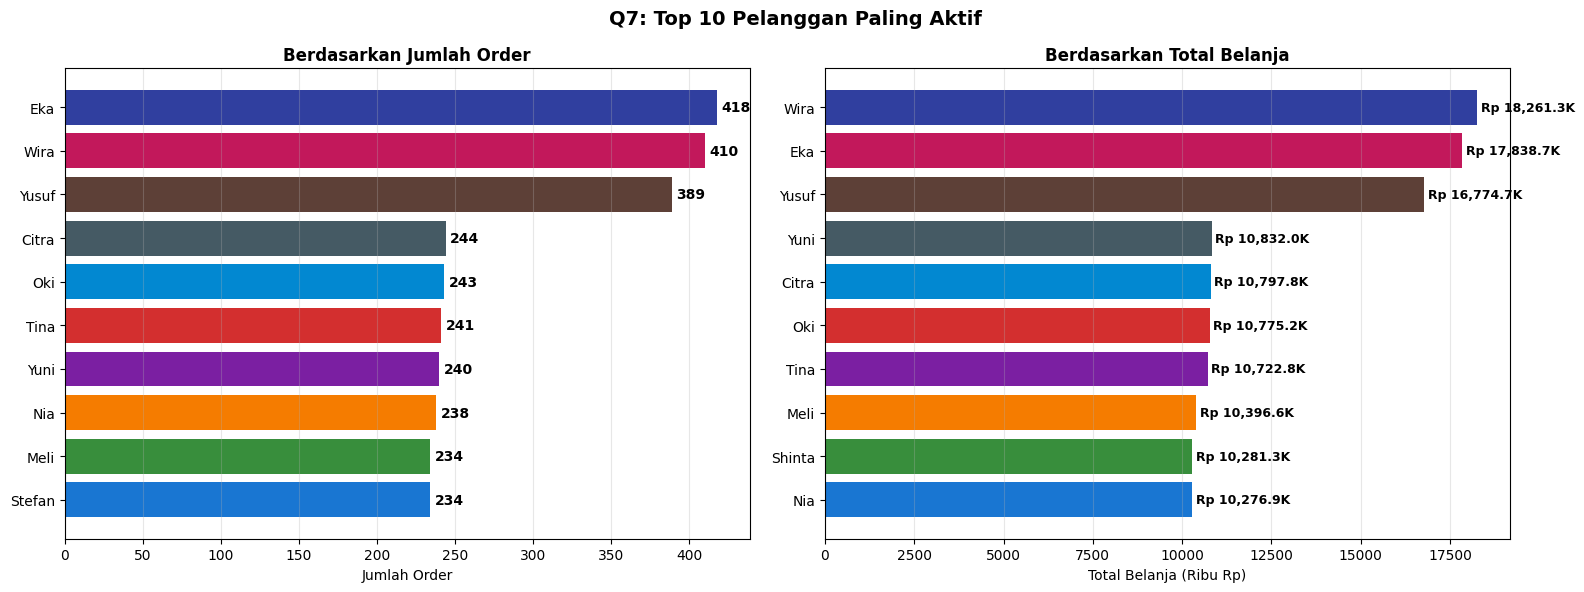

Visualisasi Q7 berhasil dibuat!


In [ ]:
# ============================================================
# VISUALISASI Q7
# ============================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 6)
)

fig.suptitle(
    'Q7: Top 10 Pelanggan Paling Aktif',
    fontsize=14,
    fontweight='bold'
)

COLORS = [
    '#1976D2',
    '#388E3C',
    '#F57C00',
    '#7B1FA2',
    '#D32F2F',
    '#0288D1',
    '#455A64',
    '#5D4037',
    '#C2185B',
    '#303F9F'
]
# ============================================================
# CHART 1: JUMLAH ORDER
# ============================================================

ax1 = axes[0]

plot_order = top_pelanggan.sort_values(
    'Jumlah_Order',
    ascending=True
)

bars = ax1.barh(
    plot_order['customer_name'],
    plot_order['Jumlah_Order'],
    color=COLORS[:len(plot_order)]
)

ax1.set_title(
    'Berdasarkan Jumlah Order',
    fontweight='bold'
)

ax1.set_xlabel('Jumlah Order')

for bar, val in zip(
    bars,
    plot_order['Jumlah_Order']
):
    ax1.text(
        bar.get_width() + 3,
        bar.get_y() + bar.get_height() / 2,
        f'{int(val):,}',
        va='center',
        fontweight='bold'
    )

ax1.grid(
    axis='x',
    alpha=0.3
)
# ============================================================
# CHART 2: TOTAL BELANJA
# ============================================================

ax2 = axes[1]

# Urutkan berdasarkan total belanja
plot_belanja = (
    df.groupby('customer_name')['total_sales']
      .sum()
      .sort_values(ascending=True)
      .tail(10)
)

bars2 = ax2.barh(
    plot_belanja.index,
    plot_belanja.values / 1000,
    color=COLORS[:len(plot_belanja)]
)

ax2.set_title(
    'Berdasarkan Total Belanja',
    fontweight='bold'
)

ax2.set_xlabel('Total Belanja (Ribu Rp)')

for bar, val in zip(
    bars2,
    plot_belanja.values
):
    ax2.text(
        bar.get_width() + 100,
        bar.get_y() + bar.get_height() / 2,
        f'Rp {val/1000:,.1f}K',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

ax2.grid(
    axis='x',
    alpha=0.3
)
plt.tight_layout()

plt.savefig(
    'top_pelanggan.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print('Visualisasi Q7 berhasil dibuat!')

In [ ]:
# ============================================================
# Q8: Kategori produk mana yang paling laris di tiap channel?
# Bandingkan performa setiap kategori (Makanan, Pembersih, Perawatan) di masing-masing channel penjualan
# (Offline, Online Toko Oren, Online Toko Hijau), mana yang mendominasi di tiap channel?
# ============================================================

kat_channel = df.groupby(['channel', 'category']).agg(
    Total_Revenue = ('total_sales', 'sum'),
    Jumlah_Order  = ('order_id', 'count'),
    Total_Qty     = ('quantity', 'sum'),
    Avg_Rating    = ('rating', 'mean')
).reset_index()

# pivot table
pivot_rev = df.pivot_table(
    index      = 'category',
    columns    = 'channel',
    values     = 'total_sales',
    aggfunc    = 'sum',
    fill_value = 0
)
pivot_rev['TOTAL'] = pivot_rev.sum(axis=1)
pivot_rev = pivot_rev.sort_values('TOTAL', ascending=False)

print('=== Q8: PIVOT TABLE REVENUE (Rp) per KATEGORI x CHANNEL ===')
print(pivot_rev.applymap(lambda x: f'Rp {x:,.0f}'))

print('\n=== KATEGORI TERLARIS PER CHANNEL ===')
for channel in df['channel'].unique():
    sub = kat_channel[kat_channel['channel'] == channel]
    top = sub.loc[sub['Total_Revenue'].idxmax()]
    print(f'{channel:<22} → {top["category"]} (Rp {top["Total_Revenue"]:,.0f}, {int(top["Jumlah_Order"])} order)')

=== Q8: PIVOT TABLE REVENUE (Rp) per KATEGORI x CHANNEL ===
channel           Offline Online - Toko Hijau Online - Toko Oren  \
category                                                           
Makanan    Rp 114,379,650      Rp 109,186,150     Rp 110,610,750   
Perawatan   Rp 96,246,300       Rp 96,836,950      Rp 94,296,400   
Pembersih   Rp 83,157,100       Rp 85,394,000      Rp 85,466,950   

channel             TOTAL  
category                   
Makanan    Rp 334,176,550  
Perawatan  Rp 287,379,650  
Pembersih  Rp 254,018,050  

=== KATEGORI TERLARIS PER CHANNEL ===
Online - Toko Oren     → Makanan (Rp 110,610,750, 2003 order)
Offline                → Makanan (Rp 114,379,650, 2056 order)
Online - Toko Hijau    → Makanan (Rp 109,186,150, 1977 order)


## Step 6: Visualisasi Dashboard

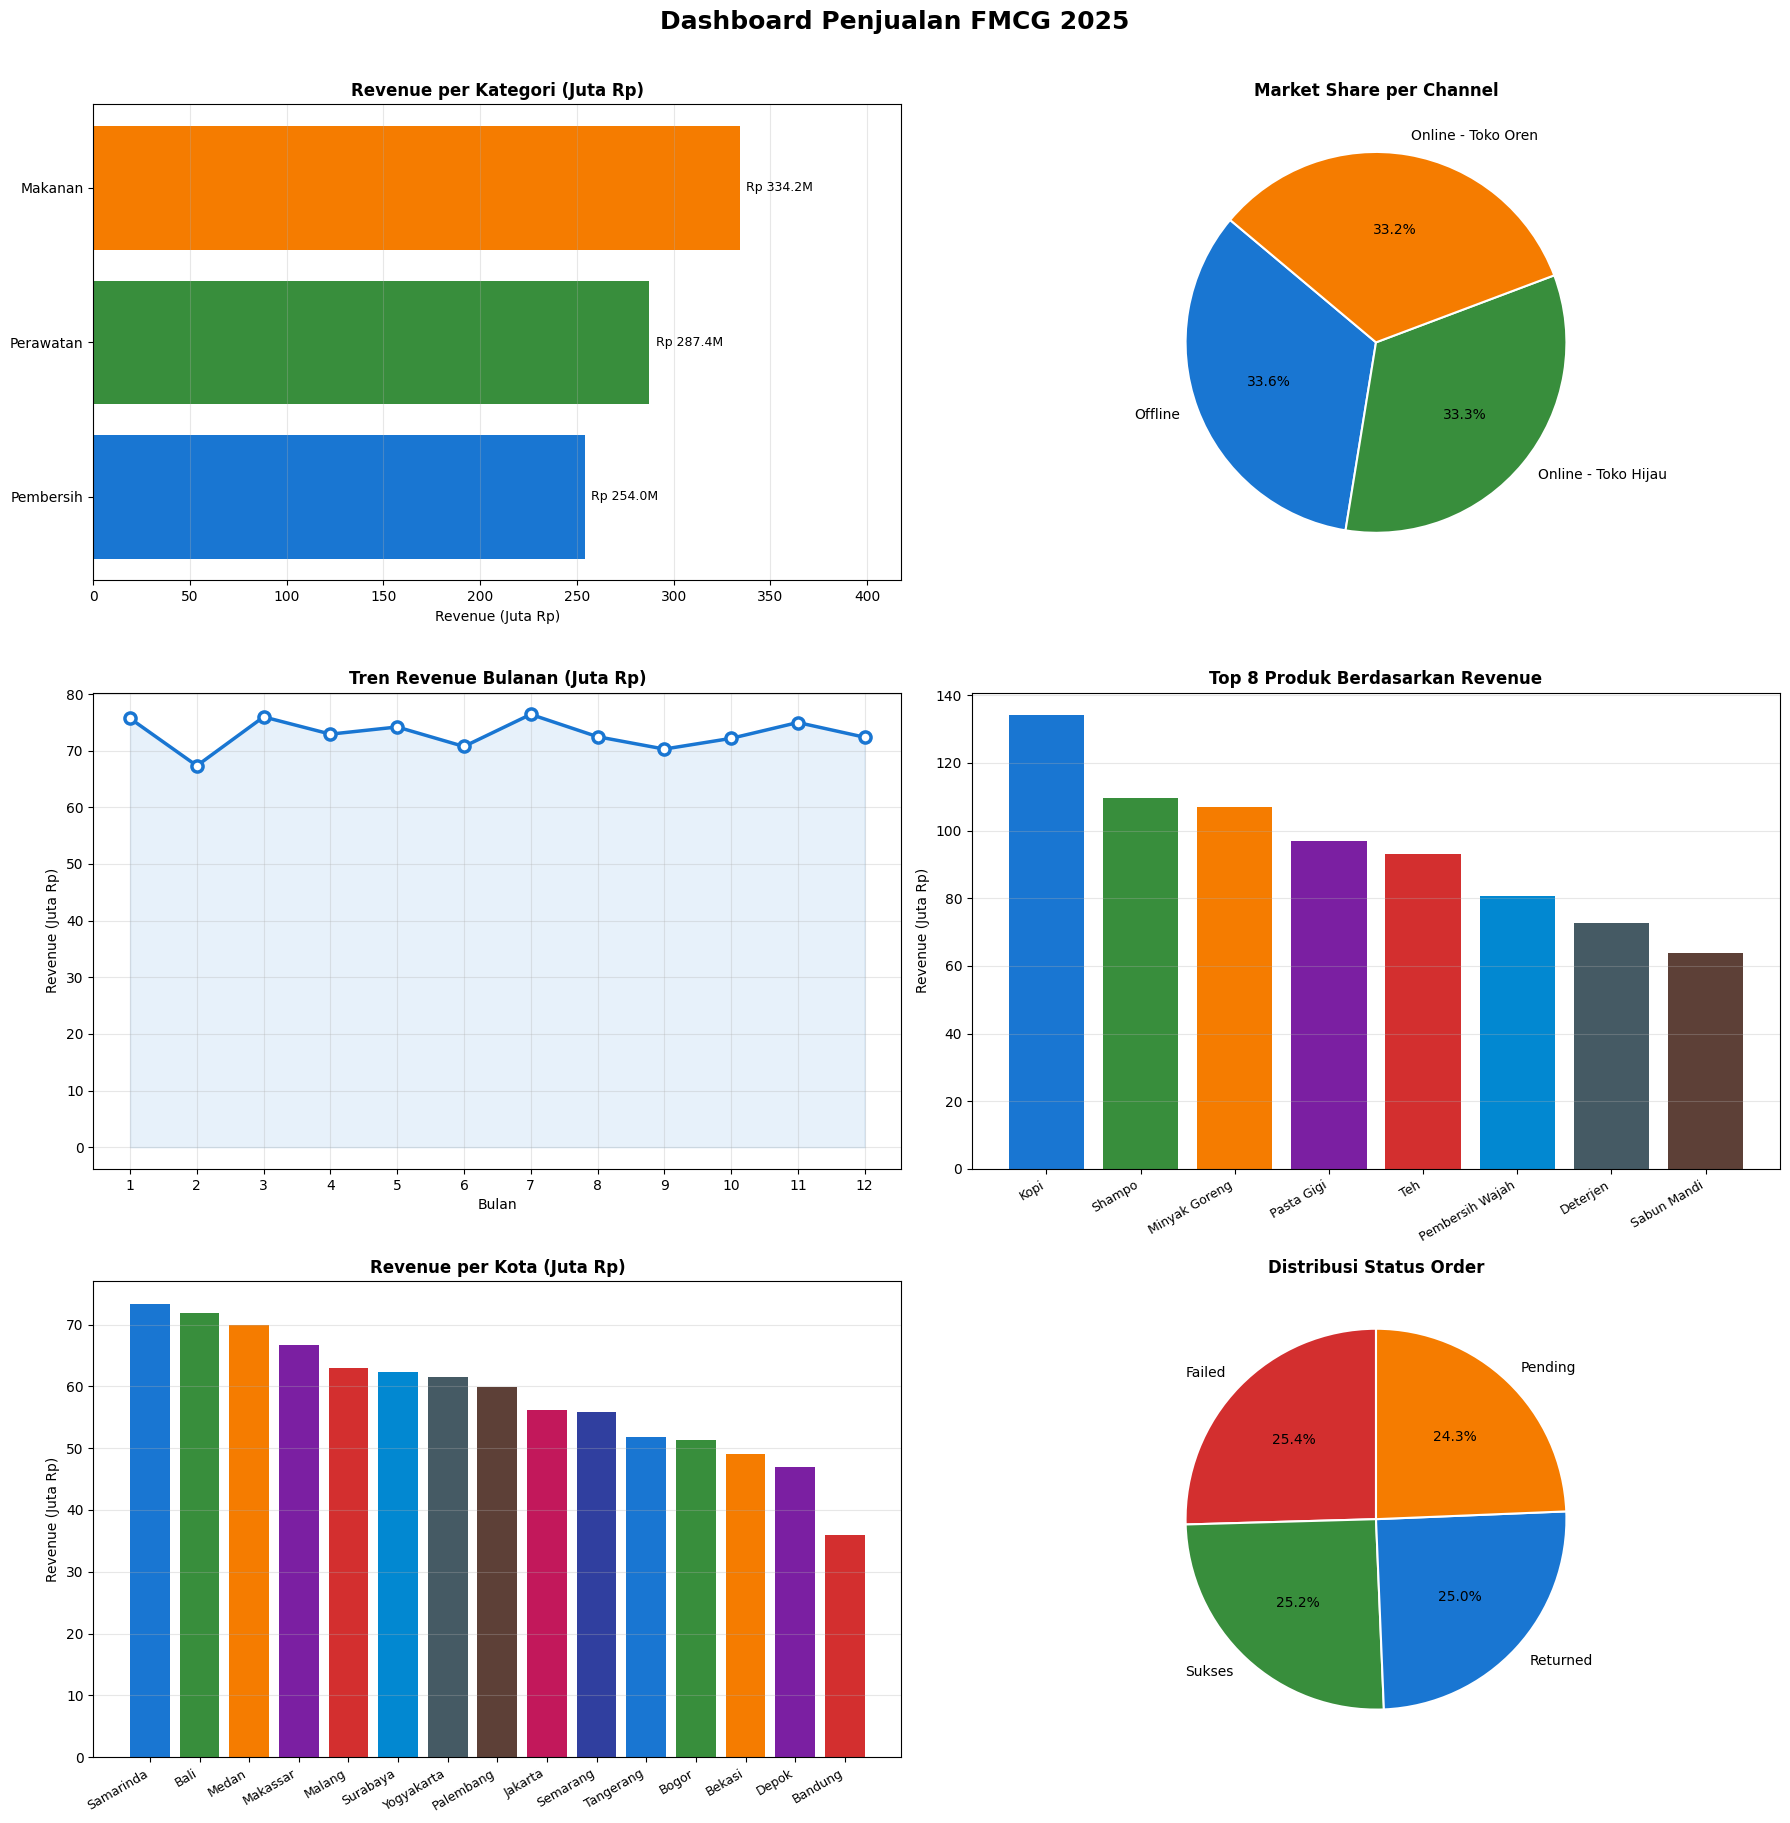

✅ Dashboard berhasil dibuat!


In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
fig.suptitle('Dashboard Penjualan FMCG 2025', fontsize=18, fontweight='bold', y=1.01)

COLORS = ['#1976D2', '#388E3C', '#F57C00', '#7B1FA2', '#D32F2F',
          '#0288D1', '#455A64', '#5D4037', '#C2185B', '#303F9F']

# --- 1. Revenue per Kategori (Horizontal Bar) ---
ax1 = axes[0, 0]
cat_data = df.groupby('category')['total_sales'].sum().sort_values()
bars = ax1.barh(cat_data.index, cat_data.values / 1e6, color=COLORS[:len(cat_data)])
ax1.set_title('Revenue per Kategori (Juta Rp)', fontweight='bold')
ax1.set_xlabel('Revenue (Juta Rp)')
for bar, val in zip(bars, cat_data.values):
    ax1.text(bar.get_width() + cat_data.max()/1e6*0.01,
             bar.get_y() + bar.get_height()/2,
             f'Rp {val/1e6:.1f}M', va='center', fontsize=9)
ax1.set_xlim(0, cat_data.max()/1e6 * 1.25)
ax1.grid(axis='x', alpha=0.3)

# --- 2. Market Share Channel (Pie) ---
ax2 = axes[0, 1]
ch_data = df.groupby('channel')['total_sales'].sum()
ax2.pie(ch_data.values, labels=ch_data.index, autopct='%1.1f%%',
        colors=COLORS[:len(ch_data)], startangle=140,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax2.set_title('Market Share per Channel', fontweight='bold')

# --- 3. Tren Bulanan (Line) ---
ax3 = axes[1, 0]
tren_data = df.groupby('month')['total_sales'].sum()
ax3.plot(tren_data.index, tren_data.values / 1e6, marker='o',
         color=COLORS[0], linewidth=2.5, markersize=8,
         markerfacecolor='white', markeredgewidth=2.5)
ax3.fill_between(tren_data.index, tren_data.values / 1e6, alpha=0.1, color=COLORS[0])
ax3.set_title('Tren Revenue Bulanan (Juta Rp)', fontweight='bold')
ax3.set_xlabel('Bulan')
ax3.set_ylabel('Revenue (Juta Rp)')
ax3.set_xticks(tren_data.index)
ax3.grid(True, alpha=0.3)

# --- 4. Top 8 Produk (Bar) ---
ax4 = axes[1, 1]
top8 = df.groupby('product_name')['total_sales'].sum().sort_values(ascending=False).head(8)
ax4.bar(range(len(top8)), top8.values / 1e6, color=COLORS[:len(top8)])
ax4.set_title('Top 8 Produk Berdasarkan Revenue', fontweight='bold')
ax4.set_ylabel('Revenue (Juta Rp)')
ax4.set_xticks(range(len(top8)))
ax4.set_xticklabels(top8.index, rotation=30, ha='right', fontsize=9)
ax4.grid(axis='y', alpha=0.3)

# --- 5. Revenue per Kota (Bar) ---
ax5 = axes[2, 0]
kota_data = df.groupby('customer_address')['total_sales'].sum().sort_values(ascending=False)
ax5.bar(range(len(kota_data)), kota_data.values / 1e6, color=COLORS[:len(kota_data)])
ax5.set_title('Revenue per Kota (Juta Rp)', fontweight='bold')
ax5.set_ylabel('Revenue (Juta Rp)')
ax5.set_xticks(range(len(kota_data)))
ax5.set_xticklabels(kota_data.index, rotation=30, ha='right', fontsize=9)
ax5.grid(axis='y', alpha=0.3)

# --- 6. Distribusi Status Order (Pie) ---
ax6 = axes[2, 1]
status_data = df['status'].value_counts()
status_colors = {'Sukses': '#388E3C', 'Pending': '#F57C00',
                 'Returned': '#1976D2', 'Failed': '#D32F2F'}
colors_status = [status_colors.get(s, '#9E9E9E') for s in status_data.index]
ax6.pie(status_data.values, labels=status_data.index, autopct='%1.1f%%',
        colors=colors_status, startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax6.set_title('Distribusi Status Order', fontweight='bold')

plt.tight_layout()
plt.savefig('dashboard_fmcg.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dashboard berhasil dibuat!')

## Step 7: Executive Summary & Business Insight

In [ ]:
total_rev       = df['total_sales'].sum()
total_order     = df['order_id'].nunique()
avg_order_val   = total_rev / total_order
sukses_rate     = (df['status'] == 'Sukses').mean() * 100
top_kat         = df.groupby('category')['total_sales'].sum().idxmax()
top_channel     = df.groupby('channel')['total_sales'].sum().idxmax()
top_produk_name = df.groupby('product_name')['total_sales'].sum().idxmax()
top_kota        = df.groupby('customer_address')['total_sales'].sum().idxmax()
avg_rating      = df['rating'].mean()
bulan_terbaik   = df.groupby('month_name')['total_sales'].sum().idxmax()

print('╔══════════════════════════════════════════════════════════════╗')
print('║          📊 RINGKASAN EKSEKUTIF - DATA FMCG 2025            ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║ Total Revenue        : Rp {total_rev:>18,.0f}                 ║')
print(f'║ Total Order          : {total_order:>10,} transaksi                  ║')
print(f'║ Avg Order Value      : Rp {avg_order_val:>18,.0f}                 ║')
print(f'║ Success Rate         : {sukses_rate:>9.1f}%                            ║')
print(f'║ Avg Rating           : {avg_rating:>9.2f} / 5                         ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║ 🏆 Kategori Teratas : {top_kat:<40}║')
print(f'║ 📱 Channel Teratas  : {top_channel:<40}║')
print(f'║ 🛍️  Produk Terlaris : {top_produk_name:<40}║')
print(f'║ 🌆 Kota Teratas     : {top_kota:<40}║')
print(f'║ 📅 Bulan Terbaik    : {bulan_terbaik:<40}║')
print('╚══════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════╗
║          📊 RINGKASAN EKSEKUTIF - DATA FMCG 2025            ║
╠══════════════════════════════════════════════════════════════╣
║ Total Revenue        : Rp        875,574,250                 ║
║ Total Order          :     20,000 transaksi                  ║
║ Avg Order Value      : Rp             43,779                 ║
║ Success Rate         :      25.2%                            ║
║ Avg Rating           :      3.00 / 5                         ║
╠══════════════════════════════════════════════════════════════╣
║ 🏆 Kategori Teratas : Makanan                                 ║
║ 📱 Channel Teratas  : Offline                                 ║
║ 🛍️  Produk Terlaris : Kopi                                    ║
║ 🌆 Kota Teratas     : Samarinda                               ║
║ 📅 Bulan Terbaik    : July                                    ║
╚══════════════════════════════════════════════════════════════╝


In [ ]:
print('=== 💡 BUSINESS INSIGHT & REKOMENDASI ===\n')

insights = [
    (
        '1. Kategori Makanan mendominasi volume transaksi',
        'Pastikan stok produk Makanan (Minyak Goreng, Kopi, Teh) selalu '
        'tersedia karena permintaannya konsisten tinggi sepanjang tahun.'
    ),
    (
        '2. Channel Offline masih menjadi kontributor terbesar revenue',
        'Pertahankan kualitas layanan offline. Paralel, dorong channel '
        'online dengan promo eksklusif untuk menggenjot pertumbuhan digital.'
    ),
    (
        '3. Persentase order Failed & Returned perlu ditekan',
        'Lakukan root-cause analysis pada order yang gagal/dikembalikan. '
        'Periksa apakah masalahnya dari produk, pengiriman, atau ekspektasi pelanggan.'
    ),
    (
        '4. Tren penjualan bulanan tidak merata',
        'Identifikasi bulan-bulan sepi dan jalankan kampanye promosi tematik '
        '(flash sale, bundling) untuk menstabilkan revenue.'
    ),
    (
        '5. Beberapa kota memiliki potensi yang belum dioptimalkan',
        'Fokus ekspansi ke kota dengan order tinggi namun average order value '
        'masih rendah melalui program loyalitas atau strategi up-selling.'
    )
]

for insight, rekomendasi in insights:
    print(f'🔍 Insight      : {insight}')
    print(f'   ✅ Rekomendasi: {rekomendasi}')
    print()

=== 💡 BUSINESS INSIGHT & REKOMENDASI ===

🔍 Insight      : 1. Kategori Makanan mendominasi volume transaksi
   ✅ Rekomendasi: Pastikan stok produk Makanan (Minyak Goreng, Kopi, Teh) selalu tersedia karena permintaannya konsisten tinggi sepanjang tahun.

🔍 Insight      : 2. Channel Offline masih menjadi kontributor terbesar revenue
   ✅ Rekomendasi: Pertahankan kualitas layanan offline. Paralel, dorong channel online dengan promo eksklusif untuk menggenjot pertumbuhan digital.

🔍 Insight      : 3. Persentase order Failed & Returned perlu ditekan
   ✅ Rekomendasi: Lakukan root-cause analysis pada order yang gagal/dikembalikan. Periksa apakah masalahnya dari produk, pengiriman, atau ekspektasi pelanggan.

🔍 Insight      : 4. Tren penjualan bulanan tidak merata
   ✅ Rekomendasi: Identifikasi bulan-bulan sepi dan jalankan kampanye promosi tematik (flash sale, bundling) untuk menstabilkan revenue.

🔍 Insight      : 5. Beberapa kota memiliki potensi yang belum dioptimalkan
   ✅ Rekomendasi: F

---

# 🎓 Ringkasan Materi

| Topik | Konsep Kunci |
|-------|--------------|
| **Introduction Python** | Variabel, Data Types, Input, Boolean, Conditional, Looping, Function |
| **Data Structure** | List, Tuple, Set, Dictionary, NumPy Array, Pandas DataFrame |
| **Data Cleansing** | Missing values, Duplicate, Outlier (IQR), Type checking |
| **Data Formatting** | Text formatting, DateTime, Type casting, Binning, Rename |
| **Case Study** | Groupby, Aggregasi, Analisis bisnis, Visualisasi, Insight |

---
**KarirNex by Ebizmark** | Bootcamp Data Analyst - Excel, SQL, Python & Power BI

📌 www.karirnex.com | @karirnex